# Data cleaning — seven-zone hourly panel

Builds an hourly panel of day-ahead prices and forecasts for seven bidding zones:
`DK1`, `DK2`, `NL`, `DE_LU`, `NO2`, `SE3`, `SE4`.

Three steps: read those zones from the raw ENTSO-E dump, collapse every series to
the clock hour, then measure what is missing.

Everything works in **UTC**, where every day has 24 hours and DST does not exist,
so a hole is a hole in what the platform published. Local market time is a later
concern.

## 1. Load

Reads the day-ahead price, load forecast and wind & solar generation forecast for
the seven zones, up to and including the hour beginning **2025-09-30 21:00 UTC**.
The zone list, the reservoir exclusion and the end of the window are applied as
predicates on the parquet scan, so only those rows are read.

The window ends there because the next hour — 2025-09-30 22:00 UTC, or
2025-10-01 00:00 CEST — is where the day-ahead market time unit becomes 15 minutes.
It is the first hour whose four quarters carry different prices in DK1, DK2, NL,
NO2, SE3 and SE4, so every price hour read is one the auction cleared as a single
hourly product. The bound covers the final hour in full: its `PT15M` slots are read
too, so it collapses from four quarters rather than from one.

Water reservoir & hydro storage [16.1.D] is excluded: it is published weekly
(`P7D`) as a stock level, not per market time unit as a flow.

Four assertions guard the read — every requested zone is defined in
`entsoe_tp.areas`, every requested zone returned rows, nothing past the window was
read, and no price hour read has quarters that differ.

In [30]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import pyarrow.parquet as pq

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 220)
pd.set_option("display.max_rows", 250)
pd.set_option("display.max_columns", 60)

# Resolve the raw dump relative to the notebook, wherever it is opened from.
CANDIDATES = [
    Path("datasets/nordic_baltic_raw.parquet"),
    Path("../datasets/nordic_baltic_raw.parquet"),
    Path("../../datasets/nordic_baltic_raw.parquet"),
]
RAW = next((p for p in CANDIDATES if p.exists()), None)
if RAW is None:
    raise FileNotFoundError(
        "nordic_baltic_raw.parquet not found. Set RAW manually to its path."
    )

# Zone timezones come from the package that produced the file, so the two cannot
# drift apart.
sys.path.insert(0, str(RAW.parent.parent))
from entsoe_tp.areas import AREAS, lookup  # noqa: E402

# --- what gets read -----------------------------------------------------------
# The zones covered, the variable left out, and the last hour taken. All three
# become predicates on the parquet scan in load_raw().
ZONES = ["DK1", "DK2", "NL", "DE_LU", "NO2", "SE3", "SE4"]
EXCLUDE_VARIABLES = ["reservoir"]

# Last hour read, labelled by its start and included in full. The next hour --
# 2025-09-30 22:00 UTC, which is 2025-10-01 00:00 CEST -- is where the day-ahead
# market time unit becomes 15 minutes, and it is the first hour whose four quarters
# differ for the DK1, DK2, NL, NO2, SE3 and SE4 prices. Stopping before it keeps
# every price hour one the auction cleared as a single hourly product.
END_UTC = pd.Timestamp("2025-09-30 21:00", tz="UTC")

unknown = sorted(set(ZONES) - set(AREAS))
assert not unknown, f"not defined in entsoe_tp.areas: {unknown}"

# psrType codes carried by the wind & solar forecast document (A69), spelled out at
# load time so every table below reads in words rather than codes. Unlisted codes
# pass through as themselves, so a new production type stays visible.
PSR_NAMES = {"B16": "solar", "B18": "wind_offshore", "B19": "wind_onshore"}

KEY = ["zone", "variable", "psr_type", "resolution", "timestamp_utc"]
CAT = ["zone", "eic", "variable", "document_type", "process_type", "resolution",
       "psr_type", "business_type", "curve_type", "contract_type", "unit", "currency"]


def load_raw(path=RAW, zones=ZONES, exclude=EXCLUDE_VARIABLES,
             end=END_UTC) -> pd.DataFrame:
    """Read the rows this pipeline uses, and normalise the dictionary-encoded columns.

    ``zones``, ``exclude`` and ``end`` are pushed into the parquet scan as row
    filters, so only the matching rows are materialised.

    Nulls become empty strings on purpose: pandas treats NaN keys as *equal* in
    duplicated()/drop_duplicates(), which silently collapses every price row
    (psr_type is null for prices) into a single group. Empty strings behave correctly.
    """
    filters = [("zone", "in", list(zones))]
    if exclude:
        filters.append(("variable", "not in", list(exclude)))
    if end is not None:
        # The bound covers the whole hour `end` labels, sub-hourly slots included,
        # so that hour collapses from a full set of quarters rather than its first.
        filters.append(("timestamp_utc", "<", end + pd.Timedelta(hours=1)))

    df = pq.read_table(path, filters=filters).to_pandas()
    for c in CAT:
        if c in df.columns:
            df[c] = df[c].astype("object").fillna("").astype(str)
    df["psr_type"] = df["psr_type"].replace(PSR_NAMES)
    df["series"] = (
        df["zone"] + " | " + df["variable"]
        + np.where(df["psr_type"] != "", " [" + df["psr_type"] + "]", "")
    )
    # Zone order follows ZONES rather than the alphabet, so every table below reads
    # in the order the thesis lists them.
    df["zone"] = pd.Categorical(df["zone"], categories=list(zones), ordered=True)
    return df


raw = load_raw()

# A zone defined in areas.py but never captured by the dump would otherwise pass
# silently as an empty slice.
absent = [z for z in ZONES if not (raw.zone == z).any()]
assert not absent, f"no rows in the dump for {absent} -- has raw_dump run for them?"
assert not set(raw.variable) & set(EXCLUDE_VARIABLES), "an excluded variable was read"
assert raw.timestamp_utc.max() < END_UTC + pd.Timedelta(hours=1), "a stamp past END_UTC"

# END_UTC exists to keep quarter-varying prices out of the panel, so that is asserted
# rather than trusted. DE-LU publishes a genuinely varying PT15M price alongside its
# hourly one from 2018 on, but every one of those hours also carries a PT60M value,
# which section 4 prefers -- so what must hold is narrower: no price hour that the
# panel would have to take from PT15M may have differing quarters.
_p = raw.loc[raw.variable == "price",
             ["series", "resolution", "timestamp_utc", "value"]].copy()
_p["hour"] = _p.timestamp_utc.dt.floor("h")
_p = _p.groupby(["series", "hour"], observed=True).agg(
    has_hourly=("resolution", lambda r: (r == "PT60M").any()),
    distinct=("value", "nunique"))
assert not ((~_p.has_hourly) & (_p.distinct > 1)).any(),     "a price hour with differing quarters and no hourly value was read"

print(f"file      : {RAW.resolve()}")
print(f"zones     : {', '.join(ZONES)}")
print(f"not read  : {', '.join(EXCLUDE_VARIABLES) if EXCLUDE_VARIABLES else '(nothing)'}")
print(f"last hour : {END_UTC}")
print(f"{len(raw):,} rows x {raw.shape[1]} columns | {raw.series.nunique()} series")
print(f"span      : {raw.timestamp_utc.min()} -> {raw.timestamp_utc.max()} (UTC)")
print(f"variables : {', '.join(sorted(raw.variable.unique()))}")

display(raw.groupby(["zone", "variable", "psr_type"], observed=True)
           .agg(rows=("value", "size"),
                resolutions=("resolution", lambda s: ",".join(sorted(s.unique()))),
                first=("timestamp_utc", "min"),
                last=("timestamp_utc", "max")))

file      : C:\Users\Frede\OneDrive\Skrivebord\Masters Thesis v2\Code\EPF_Masters\datasets\nordic_baltic_raw.parquet
zones     : DK1, DK2, NL, DE_LU, NO2, SE3, SE4
not read  : reservoir
last hour : 2025-09-30 21:00:00+00:00
4,717,756 rows x 15 columns | 33 series
span      : 2015-12-31 23:00:00+00:00 -> 2025-09-30 21:45:00+00:00 (UTC)
variables : generation_forecast, load_forecast, price


rows  resolutions                     first                      last
zone  variable            psr_type                                                                              
DK1   generation_forecast solar           97600  PT15M,PT60M 2016-01-01 00:00:00+00:00 2025-09-30 21:45:00+00:00
                          wind_offshore   97600  PT15M,PT60M 2016-01-01 00:00:00+00:00 2025-09-30 21:45:00+00:00
                          wind_onshore    97501  PT15M,PT60M 2016-01-01 00:00:00+00:00 2025-09-30 21:45:00+00:00
      load_forecast                       85462        PT60M 2016-01-01 00:00:00+00:00 2025-09-30 21:00:00+00:00
      price                               88247        PT60M 2015-12-31 23:00:00+00:00 2025-09-30 21:00:00+00:00
DK2   generation_forecast solar           97640  PT15M,PT60M 2016-01-01 00:00:00+00:00 2025-09-30 21:45:00+00:00
                          wind_offshore   97624  PT15M,PT60M 2016-01-01 00:00:00+00:00 2025-09-30 21:45:00+00:00
                          wind_onshore    97504  PT15M,PT60M 2016-01-01 00:00:00+00:00 2025-09-30 21:45:00+00:00
      load_forecast                       85462        PT60M 2016-01-01 00:00:00+00:00 2025-09-30 21:00:00+00:00
      price                               88247        PT60M 2015-12-31 23:00:00+00:00 2025-09-30 21:00:00+00:00
NL    generation_forecast solar          341656        PT15M 2016-01-01 00:00:00+00:00 2025-09-30 21:45:00+00:00
                          wind_offshore  341656        PT15M 2016-01-01 00:00:00+00:00 2025-09-30 21:45:00+00:00
                          wind_onshore   341656        PT15M 2016-01-01 00:00:00+00:00 2025-09-30 21:45:00+00:00
      load_forecast                      341848        PT15M 2016-01-01 00:00:00+00:00 2025-09-30 21:45:00+00:00
      price                               88247        PT60M 2015-12-31 23:00:00+00:00 2025-09-30 21:00:00+00:00
DE_LU generation_forecast solar          245464        PT15M 2018-09-30 22:00:00+00:00 2025-09-30 21:45:00+00:00
                          wind_offshore  245472        PT15M 2018-09-30 22:00:00+00:00 2025-09-30 21:45:00+00:00
                          wind_onshore   245464        PT15M 2018-09-30 22:00:00+00:00 2025-09-30 21:45:00+00:00
      load_forecast                      241904        PT15M 2018-10-01 00:00:00+00:00 2025-09-30 21:45:00+00:00
      price                              316920  PT15M,PT60M 2018-09-30 22:00:00+00:00 2025-09-30 21:45:00+00:00
NO2   generation_forecast solar           99659  PT15M,PT60M 2016-01-01 00:00:00+00:00 2025-09-30 21:45:00+00:00
                          wind_offshore   46122  PT15M,PT60M 2016-01-01 00:00:00+00:00 2025-09-30 21:45:00+00:00
                          wind_onshore    99659  PT15M,PT60M 2016-01-01 00:00:00+00:00 2025-09-30 21:45:00+00:00
      load_forecast                       99640  PT15M,PT60M 2016-01-01 00:00:00+00:00 2025-09-30 21:45:00+00:00
      price                              104588  PT15M,PT60M 2015-12-31 23:00:00+00:00 2025-09-30 21:45:00+00:00
SE3   generation_forecast solar           33503        PT60M 2021-12-01 23:00:00+00:00 2025-09-30 21:00:00+00:00
                          wind_onshore    85269        PT60M 2016-01-01 00:00:00+00:00 2025-09-30 21:00:00+00:00
      load_forecast                       85438        PT60M 2016-01-01 00:00:00+00:00 2025-09-30 21:00:00+00:00
      price                               88247        PT60M 2015-12-31 23:00:00+00:00 2025-09-30 21:00:00+00:00
SE4   generation_forecast solar           33503        PT60M 2021-12-01 23:00:00+00:00 2025-09-30 21:00:00+00:00
                          wind_onshore    85269        PT60M 2016-01-01 00:00:00+00:00 2025-09-30 21:00:00+00:00
      load_forecast                       85438        PT60M 2016-01-01 00:00:00+00:00 2025-09-30 21:00:00+00:00
      price                               88247        PT60M 2015-12-31 23:00:00+00:00 2025-09-30 21:00:00+00:00

## 2. Duplicate rows

Two rows sharing the full key — zone, variable, production type, resolution and
timestamp — are two copies of one observation. Downloads are chunked by month with
inclusive endpoints, so consecutive chunks overlap at the join.

Counted first, dropped second. The analysis reports how many copies each key
carries, whether those copies agree on their value, and where the duplicated
stamps sit in the calendar month. A key whose copies disagree is one where
`keep="first"` selects between different numbers.

In [31]:
dup_any = raw.duplicated(KEY, keep=False)
redundant = int(raw.duplicated(KEY, keep="first").sum())

print(f"rows on a duplicated key: {int(dup_any.sum()):,} of {len(raw):,}")
print(f"redundant copies        : {redundant:,}")
print(f"keys carrying them      : {int(dup_any.sum()) - redundant:,}")

if not redundant:
    print("\nno duplicate keys")
else:
    # `series` encodes zone, variable and psr_type, so this grouping is the full key.
    per_key = (raw.loc[dup_any]
                  .groupby(["series", "resolution", "timestamp_utc"], observed=True)["value"]
                  .agg(copies="size", distinct="nunique", lo="min", hi="max"))
    per_key["spread"] = per_key["hi"] - per_key["lo"]
    pk = per_key.reset_index()

    print("\ncopies per duplicated key:")
    display(pk.copies.value_counts().sort_index()
              .rename_axis("copies").to_frame("keys"))

    # A key whose copies disagree makes keep="first" a choice rather than a formality.
    conflicting = pk[pk.distinct > 1]
    print(f"keys whose copies disagree on value: {len(conflicting):,} of {len(pk):,}")
    if len(conflicting):
        print("largest disagreements:")
        display(conflicting.nlargest(20, "spread").reset_index(drop=True))

    print("\nper series:")
    display(pk.groupby("series", observed=True)
              .agg(duplicated_stamps=("timestamp_utc", "size"),
                   redundant_copies=("copies", lambda c: int((c - 1).sum())),
                   disagreeing=("distinct", lambda x: int((x > 1).sum())),
                   max_spread=("spread", "max"),
                   first=("timestamp_utc", "min"),
                   last=("timestamp_utc", "max")))

    print("\nwhere the duplicated stamps sit in the month:")
    display(pk.timestamp_utc.dt.day.value_counts().sort_index()
              .rename_axis("day_of_month").to_frame("duplicated_stamps"))

rows on a duplicated key: 54,576 of 4,717,756
redundant copies        : 27,288
keys carrying them      : 27,288

copies per duplicated key:


,keys
copies,
2,27288


keys whose copies disagree on value: 0 of 27,288

per series:


,duplicated_stamps,redundant_copies,disagreeing,max_spread,first,last
series,,,,,,
DE_LU | price,10080,10080,0,0.0,2018-09-30 22:00:00+00:00,2025-09-01 21:45:00+00:00
DK1 | price,2784,2784,0,0.0,2016-01-31 23:00:00+00:00,2025-09-01 21:00:00+00:00
DK2 | price,2784,2784,0,0.0,2016-01-31 23:00:00+00:00,2025-09-01 21:00:00+00:00
NL | price,2784,2784,0,0.0,2016-01-31 23:00:00+00:00,2025-09-01 21:00:00+00:00
NO2 | price,3288,3288,0,0.0,2016-01-31 23:00:00+00:00,2025-09-01 21:45:00+00:00
SE3 | price,2784,2784,0,0.0,2016-01-31 23:00:00+00:00,2025-09-01 21:00:00+00:00
SE4 | price,2784,2784,0,0.0,2016-01-31 23:00:00+00:00,2025-09-01 21:00:00+00:00



where the duplicated stamps sit in the month:


,duplicated_stamps
day_of_month,
1,25474
28,70
29,28
30,659
31,1057


In [32]:
# Having been counted and characterised above, the redundant copies are dropped.
n = len(raw)
deduped = raw.drop_duplicates(KEY, keep="first").copy()

assert not deduped.duplicated(KEY).any(), "a duplicate key survived"
print(f"drop redundant copies: {n:,} -> {len(deduped):,}  (-{n - len(deduped):,})")

drop redundant copies: 4,717,756 -> 4,690,468  (-27,288)


## 3. Do the PT15M quarters vary within the hour?

A `PT15M` stamp does not by itself mean quarter-hourly data. A zone that switched
its publication format before the auction cleared sub-hourly repeats one hourly
value across all four quarters, and a zone publishing a genuinely quarter-hourly
product does not.

The distinction decides what the collapse in section 4 does. Where the four values
of an hour are identical, the mean returns that value exactly. Where they differ,
the mean is a summary of four separate values.

Per series below: how many `PT15M` hours vary within the hour, the first hour that
varies, the largest within-hour spread, and the monthly share of varying hours.
Hours whose four values are all zero are counted separately as inactive.

In [33]:
q = deduped.loc[deduped.resolution == "PT15M",
                ["series", "timestamp_utc", "value"]].copy()

if not len(q):
    print("no PT15M rows")
else:
    q["hour_utc"] = q.timestamp_utc.dt.floor("h")

    per_hour = (q.groupby(["series", "hour_utc"], observed=True)["value"]
                  .agg(slots="size", distinct="nunique", lo="min", hi="max"))
    per_hour["spread"] = per_hour["hi"] - per_hour["lo"]
    per_hour["varies"] = per_hour["distinct"] > 1
    # An all-zero hour cannot vary, so it is counted apart: solar at night would
    # otherwise drag the varying share down.
    per_hour["active"] = per_hour[["lo", "hi"]].abs().max(axis=1) > 1e-9
    ph = per_hour.reset_index()

    print(f"{len(ph):,} PT15M hours across {ph.series.nunique()} series | "
          f"{int(ph.varies.sum()):,} vary within the hour ({100 * ph.varies.mean():.2f}%)")

    active = ph[ph.active]
    first_varying = (ph[ph.varies].groupby("series", observed=True)["hour_utc"]
                       .min().rename("first_varying_hour"))
    pct_active = (100 * active.groupby("series", observed=True)["varies"].mean()
                  ).round(2).rename("pct_varying_active")

    summary = (ph.groupby("series", observed=True)
                 .agg(pt15_hours=("varies", "size"),
                      varying=("varies", "sum"),
                      inactive_hours=("active", lambda a: int((~a).sum())),
                      max_spread=("spread", "max"),
                      first_pt15=("hour_utc", "min"),
                      last_pt15=("hour_utc", "max"))
                 .join(first_varying)
                 .join(pct_active))
    summary["pct_varying"] = (100 * summary.varying / summary.pt15_hours).round(2)
    display(summary)

    print("\nmonthly share of active PT15M hours that vary within the hour:")
    display(active.assign(month=active.hour_utc.dt.tz_convert(None).dt.to_period("M"))
                  .pivot_table(index="month", columns="series", values="varies",
                               aggfunc="mean")
                  .round(3))

692,513 PT15M hours across 20 series | 615,753 vary within the hour (88.92%)


,pt15_hours,varying,inactive_hours,max_spread,first_pt15,last_pt15,first_varying_hour,pct_varying_active,pct_varying
series,,,,,,,,,
DE_LU | generation_forecast [solar],61366,35206,26160,9900.54,2018-09-30 22:00:00+00:00,2025-09-30 21:00:00+00:00,2018-10-01 05:00:00+00:00,100.00,57.37
DE_LU | generation_forecast [wind_offshore],61368,61368,0,1214.59,2018-09-30 22:00:00+00:00,2025-09-30 21:00:00+00:00,2018-09-30 22:00:00+00:00,100.00,100.00
DE_LU | generation_forecast [wind_onshore],61366,61366,0,4895.60,2018-09-30 22:00:00+00:00,2025-09-30 21:00:00+00:00,2018-09-30 22:00:00+00:00,100.00,100.00
DE_LU | load_forecast,60476,60476,0,9734.89,2018-10-01 00:00:00+00:00,2025-09-30 21:00:00+00:00,2018-10-01 00:00:00+00:00,100.00,100.00
DE_LU | price,61368,61364,0,3149.98,2018-09-30 22:00:00+00:00,2025-09-30 21:00:00+00:00,2018-09-30 22:00:00+00:00,99.99,99.99
DK1 | generation_forecast [solar],4174,3550,332,584.15,2025-04-08 00:00:00+00:00,2025-09-30 21:00:00+00:00,2025-04-10 01:00:00+00:00,92.40,85.05
DK1 | generation_forecast [wind_offshore],4126,4098,2,213.50,2025-04-08 00:00:00+00:00,2025-09-30 21:00:00+00:00,2025-04-09 22:00:00+00:00,99.37,99.32
DK1 | generation_forecast [wind_onshore],4132,4108,0,312.83,2025-04-08 00:00:00+00:00,2025-09-30 21:00:00+00:00,2025-04-09 00:00:00+00:00,99.42,99.42
DK2 | generation_forecast [solar],4172,3366,523,198.72,2025-04-08 00:00:00+00:00,2025-09-30 21:00:00+00:00,2025-04-10 03:00:00+00:00,92.24,80.68



monthly share of active PT15M hours that vary within the hour:


series,DE_LU | generation_forecast [solar],DE_LU | generation_forecast [wind_offshore],DE_LU | generation_forecast [wind_onshore],DE_LU | load_forecast,DE_LU | price,DK1 | generation_forecast [solar],DK1 | generation_forecast [wind_offshore],DK1 | generation_forecast [wind_onshore],DK2 | generation_forecast [solar],DK2 | generation_forecast [wind_offshore],DK2 | generation_forecast [wind_onshore],NL | generation_forecast [solar],NL | generation_forecast [wind_offshore],NL | generation_forecast [wind_onshore],NL | load_forecast,NO2 | generation_forecast [wind_offshore],NO2 | generation_forecast [wind_onshore],NO2 | load_forecast,NO2 | price
month,,,,,,,,,,,,,,,,,,,
2016-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.997,0.918,1.000,1.0,NaN,NaN,NaN,NaN
2016-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000,0.920,0.996,1.0,NaN,NaN,NaN,NaN
2016-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000,0.944,1.000,1.0,NaN,NaN,NaN,NaN
2016-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000,0.954,0.999,1.0,NaN,NaN,NaN,NaN
2016-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000,0.930,0.995,1.0,NaN,NaN,NaN,NaN
2016-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.998,0.940,0.999,1.0,NaN,NaN,NaN,NaN
2016-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.998,0.938,0.997,1.0,NaN,NaN,NaN,NaN
2016-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.996,0.935,0.999,1.0,NaN,NaN,NaN,NaN
2016-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.998,0.918,0.994,1.0,NaN,NaN,NaN,NaN


## 4. Collapse to the clock hour

Native resolutions differ across the seven zones. NL publishes its load and
generation forecasts at `PT15M` for its whole history and DE-LU from 2018; DK1,
DK2 and NO2 switch from `PT60M` to `PT15M` during 2025; SE3 and SE4 are hourly
throughout. This step puts them all on one hourly grid.

Two things are decided here, and each is reported:

1. **Sub-hourly values are averaged within the clock hour.** For an MW quantity
   that is the hourly average. For a price it is an unweighted mean of the
   quarters; the dump carries no traded volumes to weight by. Where section 3 shows
   the four quarters are identical the mean returns that value exactly. Hours
   arriving with fewer slots than their resolution implies are counted separately —
   the mean is then taken over part of an hour.

2. **An hour carrying both resolutions takes the `PT60M` value.** Several price
   series are published at both resolutions over overlapping spans; the `PT15M`
   mean fills only the hours `PT60M` does not cover. The disagreement between the
   two versions is measured and reported.

In [34]:
# Slots per clock hour, which is also the guard: anything coarser than an hour would
# be relabelled PT60M by the collapse below. The weekly reservoir series is never
# read (section 1), so this only guards a future change to EXCLUDE_VARIABLES.
SLOTS_PER_HOUR = {"PT60M": 1, "PT15M": 4}

stray = sorted(set(deduped.resolution.unique()) - set(SLOTS_PER_HOUR))
assert not stray, f"resolution(s) {stray} are coarser than an hour"

# 1. collapse to the clock hour, per resolution, so a PT60M value is never averaged
# together with the PT15M quarters of the same hour
d = deduped.copy()
d["hour_utc"] = d.timestamp_utc.dt.floor("h")
GROUP = [c for c in ["zone", "eic", "variable", "document_type", "process_type",
                     "psr_type", "business_type", "curve_type", "contract_type",
                     "unit", "currency", "series", "resolution", "hour_utc"]
         if c in d.columns]

folded = (d.groupby(GROUP, as_index=False, observed=True)
            .agg(value=("value", "mean"), slots=("value", "size")))
print(f"1. collapse to the hour: {len(d):,} -> {len(folded):,}  (-{len(d) - len(folded):,})")

folded["expected_slots"] = folded.resolution.map(SLOTS_PER_HOUR)
partial = folded[folded.slots < folded.expected_slots]
print(f"   partial hours       : {len(partial):,} "
      f"({100 * len(partial) / len(folded):.4f}% of collapsed hours)")

1. collapse to the hour: 4,690,468 -> 2,612,932  (-2,077,536)
   partial hours       : 1 (0.0000% of collapsed hours)


In [35]:
# 2. hours carrying both resolutions: how far do the two published versions differ?
overlap = folded.pivot_table(index=["series", "hour_utc"], columns="resolution",
                             values="value", aggfunc="first")
pair = [c for c in ("PT60M", "PT15M") if c in overlap.columns]

if len(pair) == 2:
    both = overlap.dropna(subset=pair).copy()
    both["abs_diff"] = (both["PT60M"] - both["PT15M"]).abs()
    print(f"hours published at both resolutions: {len(both):,}")
    if len(both):
        display(both.reset_index().groupby("series", observed=True)
                    .agg(hours=("abs_diff", "size"),
                         max_abs_diff=("abs_diff", "max"),
                         median_abs_diff=("abs_diff", "median"),
                         hours_differing=("abs_diff", lambda s: int((s > 1e-9).sum())),
                         first=("hour_utc", "min"), last=("hour_utc", "max")))
else:
    print("only one resolution present; nothing to reconcile")

hours published at both resolutions: 61,368


,hours,max_abs_diff,median_abs_diff,hours_differing,first,last
series,,,,,,
DE_LU | price,61368,678.775,4.1175,61335,2018-09-30 22:00:00+00:00,2025-09-30 21:00:00+00:00


In [36]:
# PT60M wins where an hour carries both; the PT15M mean fills the rest.
PRECEDENCE = ["PT60M", "PT15M"]

folded["_rank"] = folded.resolution.map({r: i for i, r in enumerate(PRECEDENCE)})
hourly = (folded.sort_values(["series", "hour_utc", "_rank"])
                .drop_duplicates(["series", "hour_utc"], keep="first")
                .drop(columns="_rank")
                .rename(columns={"hour_utc": "timestamp_utc",
                                 "resolution": "source_resolution"})
                .reset_index(drop=True))

assert not hourly.duplicated(["series", "timestamp_utc"]).any(), \
    "a series still has two values for one hour"
assert hourly.timestamp_utc.dt.minute.eq(0).all(), "a stamp is not on the hour"

print(f"3. one row per series-hour: {len(folded):,} -> {len(hourly):,}  "
      f"(-{len(folded) - len(hourly):,})")
print(f"\n{len(hourly):,} rows | {hourly.series.nunique()} series | "
      f"{hourly.zone.nunique()} zones")
print(f"span: {hourly.timestamp_utc.min()} -> {hourly.timestamp_utc.max()} (UTC)")

display(hourly.groupby(["zone", "variable", "psr_type"], observed=True)
              .agg(hours=("value", "size"),
                   source=("source_resolution", lambda s: ",".join(sorted(s.unique()))),
                   first=("timestamp_utc", "min"),
                   last=("timestamp_utc", "max")))

3. one row per series-hour: 2,612,932 -> 2,551,564  (-61,368)

2,551,564 rows | 33 series | 7 zones
span: 2015-12-31 23:00:00+00:00 -> 2025-09-30 21:00:00+00:00 (UTC)


hours       source                     first                      last
zone  variable            psr_type                                                                             
DK1   generation_forecast solar          85078  PT15M,PT60M 2016-01-01 00:00:00+00:00 2025-09-30 21:00:00+00:00
                          wind_offshore  85222  PT15M,PT60M 2016-01-01 00:00:00+00:00 2025-09-30 21:00:00+00:00
                          wind_onshore   85108  PT15M,PT60M 2016-01-01 00:00:00+00:00 2025-09-30 21:00:00+00:00
      load_forecast                      85462        PT60M 2016-01-01 00:00:00+00:00 2025-09-30 21:00:00+00:00
      price                              85463        PT60M 2015-12-31 23:00:00+00:00 2025-09-30 21:00:00+00:00
DK2   generation_forecast solar          85124  PT15M,PT60M 2016-01-01 00:00:00+00:00 2025-09-30 21:00:00+00:00
                          wind_offshore  85246  PT15M,PT60M 2016-01-01 00:00:00+00:00 2025-09-30 21:00:00+00:00
                          wind_onshore   85126  PT15M,PT60M 2016-01-01 00:00:00+00:00 2025-09-30 21:00:00+00:00
      load_forecast                      85462        PT60M 2016-01-01 00:00:00+00:00 2025-09-30 21:00:00+00:00
      price                              85463        PT60M 2015-12-31 23:00:00+00:00 2025-09-30 21:00:00+00:00
NL    generation_forecast solar          85414        PT15M 2016-01-01 00:00:00+00:00 2025-09-30 21:00:00+00:00
                          wind_offshore  85414        PT15M 2016-01-01 00:00:00+00:00 2025-09-30 21:00:00+00:00
                          wind_onshore   85414        PT15M 2016-01-01 00:00:00+00:00 2025-09-30 21:00:00+00:00
      load_forecast                      85462        PT15M 2016-01-01 00:00:00+00:00 2025-09-30 21:00:00+00:00
      price                              85463        PT60M 2015-12-31 23:00:00+00:00 2025-09-30 21:00:00+00:00
DE_LU generation_forecast solar          61366        PT15M 2018-09-30 22:00:00+00:00 2025-09-30 21:00:00+00:00
                          wind_offshore  61368        PT15M 2018-09-30 22:00:00+00:00 2025-09-30 21:00:00+00:00
                          wind_onshore   61366        PT15M 2018-09-30 22:00:00+00:00 2025-09-30 21:00:00+00:00
      load_forecast                      60476        PT15M 2018-10-01 00:00:00+00:00 2025-09-30 21:00:00+00:00
      price                              61368        PT60M 2018-09-30 22:00:00+00:00 2025-09-30 21:00:00+00:00
NO2   generation_forecast solar          85409  PT15M,PT60M 2016-01-01 00:00:00+00:00 2025-09-30 21:00:00+00:00
                          wind_offshore  44610  PT15M,PT60M 2016-01-01 00:00:00+00:00 2025-09-30 21:00:00+00:00
                          wind_onshore   85409  PT15M,PT60M 2016-01-01 00:00:00+00:00 2025-09-30 21:00:00+00:00
      load_forecast                      85462  PT15M,PT60M 2016-01-01 00:00:00+00:00 2025-09-30 21:00:00+00:00
      price                              85463  PT15M,PT60M 2015-12-31 23:00:00+00:00 2025-09-30 21:00:00+00:00
SE3   generation_forecast solar          33503        PT60M 2021-12-01 23:00:00+00:00 2025-09-30 21:00:00+00:00
                          wind_onshore   85269        PT60M 2016-01-01 00:00:00+00:00 2025-09-30 21:00:00+00:00
      load_forecast                      85438        PT60M 2016-01-01 00:00:00+00:00 2025-09-30 21:00:00+00:00
      price                              85463        PT60M 2015-12-31 23:00:00+00:00 2025-09-30 21:00:00+00:00
SE4   generation_forecast solar          33503        PT60M 2021-12-01 23:00:00+00:00 2025-09-30 21:00:00+00:00
                          wind_onshore   85269        PT60M 2016-01-01 00:00:00+00:00 2025-09-30 21:00:00+00:00
      load_forecast                      85438        PT60M 2016-01-01 00:00:00+00:00 2025-09-30 21:00:00+00:00
      price                              85463        PT60M 2015-12-31 23:00:00+00:00 2025-09-30 21:00:00+00:00

## 5. Trim to the common start

The series do not begin together. DK, NL, NO2 and SE run from 2016; DE-LU enters
the dump on 2018-09-30, and its load forecast on 2018-10-01. The panel starts there.

A series whose own record begins later than that cannot cover the panel's span, so
it is dropped rather than carried as a column that is empty for years: SE3 and SE4
solar, first published on 2021-12-01. Both the cut and the dropped series are
reported.

In [46]:
# The hour from which the panel runs.
START_UTC = pd.Timestamp("2018-10-01 00:00", tz="UTC")

firsts = hourly.groupby("series", observed=True)["timestamp_utc"].min().sort_values()
late = firsts[firsts > START_UTC]

# Drop the series that begin after the cut, then drop the hours before it.
panel = hourly[~hourly.series.isin(late.index)]
panel = panel[panel.timestamp_utc >= START_UTC].copy()

assert not late.index.isin(panel.series.unique()).any(), "a dropped series survived"
assert panel.timestamp_utc.min() >= START_UTC, "an hour before the cut survived"

if not len(late):
    print("every series begins at or before the cut; none dropped")
else:
    print(f"drop {len(late)} series beginning after {START_UTC:%Y-%m-%d}:")
    display(late.rename("first_hour").to_frame().assign(
        days_after_start=lambda d: ((d.first_hour - START_UTC)
                                    / pd.Timedelta(days=1)).round(1)))

print(f"series: {hourly.series.nunique()} -> {panel.series.nunique()}")
print(f"rows  : {len(hourly):,} -> {len(panel):,}  (-{len(hourly) - len(panel):,})")
print(f"span  : {panel.timestamp_utc.min()} -> {panel.timestamp_utc.max()} (UTC)")

display(panel.groupby(["zone", "variable", "psr_type"], observed=True)
             .agg(hours=("value", "size"),
                  first=("timestamp_utc", "min"),
                  last=("timestamp_utc", "max")))

drop 2 series beginning after 2018-10-01:


,first_hour,days_after_start
series,,
SE3 | generation_forecast [solar],2021-12-01 23:00:00+00:00,1158.0
SE4 | generation_forecast [solar],2021-12-01 23:00:00+00:00,1158.0


series: 33 -> 31
rows  : 2,551,564 -> 1,858,318  (-693,246)
span  : 2018-10-01 00:00:00+00:00 -> 2025-09-30 21:00:00+00:00 (UTC)


hours                     first                      last
zone  variable            psr_type                                                                
DK1   generation_forecast solar          60982 2018-10-01 00:00:00+00:00 2025-09-30 21:00:00+00:00
                          wind_offshore  61150 2018-10-01 00:00:00+00:00 2025-09-30 21:00:00+00:00
                          wind_onshore   61060 2018-10-01 00:00:00+00:00 2025-09-30 21:00:00+00:00
      load_forecast                      61366 2018-10-01 00:00:00+00:00 2025-09-30 21:00:00+00:00
      price                              61366 2018-10-01 00:00:00+00:00 2025-09-30 21:00:00+00:00
DK2   generation_forecast solar          61028 2018-10-01 00:00:00+00:00 2025-09-30 21:00:00+00:00
                          wind_offshore  61150 2018-10-01 00:00:00+00:00 2025-09-30 21:00:00+00:00
                          wind_onshore   61054 2018-10-01 00:00:00+00:00 2025-09-30 21:00:00+00:00
      load_forecast                      61366 2018-10-01 00:00:00+00:00 2025-09-30 21:00:00+00:00
      price                              61366 2018-10-01 00:00:00+00:00 2025-09-30 21:00:00+00:00
NL    generation_forecast solar          61342 2018-10-01 00:00:00+00:00 2025-09-30 21:00:00+00:00
                          wind_offshore  61342 2018-10-01 00:00:00+00:00 2025-09-30 21:00:00+00:00
                          wind_onshore   61342 2018-10-01 00:00:00+00:00 2025-09-30 21:00:00+00:00
      load_forecast                      61366 2018-10-01 00:00:00+00:00 2025-09-30 21:00:00+00:00
      price                              61366 2018-10-01 00:00:00+00:00 2025-09-30 21:00:00+00:00
DE_LU generation_forecast solar          61364 2018-10-01 00:00:00+00:00 2025-09-30 21:00:00+00:00
                          wind_offshore  61366 2018-10-01 00:00:00+00:00 2025-09-30 21:00:00+00:00
                          wind_onshore   61364 2018-10-01 00:00:00+00:00 2025-09-30 21:00:00+00:00
      load_forecast                      60476 2018-10-01 00:00:00+00:00 2025-09-30 21:00:00+00:00
      price                              61366 2018-10-01 00:00:00+00:00 2025-09-30 21:00:00+00:00
NO2   generation_forecast solar          61315 2018-10-01 00:00:00+00:00 2025-09-30 21:00:00+00:00
                          wind_offshore  20516 2018-10-01 00:00:00+00:00 2025-09-30 21:00:00+00:00
                          wind_onshore   61315 2018-10-01 00:00:00+00:00 2025-09-30 21:00:00+00:00
      load_forecast                      61366 2018-10-01 00:00:00+00:00 2025-09-30 21:00:00+00:00
      price                              61366 2018-10-01 00:00:00+00:00 2025-09-30 21:00:00+00:00
SE3   generation_forecast wind_onshore   61197 2018-10-01 00:00:00+00:00 2025-09-30 21:00:00+00:00
      load_forecast                      61366 2018-10-01 00:00:00+00:00 2025-09-30 21:00:00+00:00
      price                              61366 2018-10-01 00:00:00+00:00 2025-09-30 21:00:00+00:00
SE4   generation_forecast wind_onshore   61197 2018-10-01 00:00:00+00:00 2025-09-30 21:00:00+00:00
      load_forecast                      61366 2018-10-01 00:00:00+00:00 2025-09-30 21:00:00+00:00
      price                              61366 2018-10-01 00:00:00+00:00 2025-09-30 21:00:00+00:00

## 6. Missing-value analysis

All series are now on the same hourly UTC grid, over one common span. Three descriptive views; nothing
is filled, dropped or truncated here.

**Coverage**: hours published against hours spanned, between each series' own first
and last observation. A late start or an early stop shows in `first`/`last`, so
this measures interior holes. `partial_hours` counts hours that are present but
were collapsed from fewer slots than their resolution implies.

**Gap runs**: consecutive missing hours grouped into runs, with start, end and
length.

**Monthly coverage**: the share of each month's hours that were published, per
series.

In [38]:
def coverage(d: pd.DataFrame) -> pd.DataFrame:
    """Observed vs expected hours per series, between its own first and last stamp."""
    rows = []
    for s, g in d.groupby("series", observed=True):
        stamps = pd.DatetimeIndex(g.timestamp_utc.unique()).sort_values()
        grid = pd.date_range(stamps.min(), stamps.max(), freq="h")
        missing = len(grid) - len(stamps)
        rows.append({
            "series": s,
            "first": stamps.min(),
            "last": stamps.max(),
            "hours_spanned": len(grid),
            "observed": len(stamps),
            "missing": missing,
            "pct_missing": round(100 * missing / len(grid), 4),
            "partial_hours": int((g.slots < g.expected_slots).sum()),
        })
    return pd.DataFrame(rows).sort_values("series", ignore_index=True)


cov = coverage(panel)
print(f"{int(cov.missing.sum()):,} missing hours across {len(cov)} series "
      f"({int((cov.missing > 0).sum())} series with at least one)")
display(cov)

44,028 missing hours across 31 series (17 series with at least one)


,series,first,last,hours_spanned,observed,missing,pct_missing,partial_hours
0,DE_LU | generation_forecast [solar],2018-10-01 00:00:00+00:00,2025-09-30 21:00:00+00:00,61366,61364,2,0.0033,0
1,DE_LU | generation_forecast [wind_offshore],2018-10-01 00:00:00+00:00,2025-09-30 21:00:00+00:00,61366,61366,0,0.0000,0
2,DE_LU | generation_forecast [wind_onshore],2018-10-01 00:00:00+00:00,2025-09-30 21:00:00+00:00,61366,61364,2,0.0033,0
3,DE_LU | load_forecast,2018-10-01 00:00:00+00:00,2025-09-30 21:00:00+00:00,61366,60476,890,1.4503,0
4,DE_LU | price,2018-10-01 00:00:00+00:00,2025-09-30 21:00:00+00:00,61366,61366,0,0.0000,0
5,DK1 | generation_forecast [solar],2018-10-01 00:00:00+00:00,2025-09-30 21:00:00+00:00,61366,60982,384,0.6258,0
6,DK1 | generation_forecast [wind_offshore],2018-10-01 00:00:00+00:00,2025-09-30 21:00:00+00:00,61366,61150,216,0.3520,0
7,DK1 | generation_forecast [wind_onshore],2018-10-01 00:00:00+00:00,2025-09-30 21:00:00+00:00,61366,61060,306,0.4986,1
8,DK1 | load_forecast,2018-10-01 00:00:00+00:00,2025-09-30 21:00:00+00:00,61366,61366,0,0.0000,0
9,DK1 | price,2018-10-01 00:00:00+00:00,2025-09-30 21:00:00+00:00,61366,61366,0,0.0000,0


In [39]:
def gap_runs(d: pd.DataFrame) -> pd.DataFrame:
    """Every run of consecutive missing hours, per series."""
    runs = []
    for s, g in d.groupby("series", observed=True):
        stamps = pd.DatetimeIndex(g.timestamp_utc.unique()).sort_values()
        grid = pd.date_range(stamps.min(), stamps.max(), freq="h")
        missing = grid.difference(stamps)
        if not len(missing):
            continue
        gap = missing.to_series()
        breaks = (gap.diff() != pd.Timedelta(hours=1)).cumsum()
        for _, run in gap.groupby(breaks):
            runs.append({"series": s, "gap_start": run.index[0],
                         "gap_end": run.index[-1], "hours": len(run)})
    return pd.DataFrame(runs, columns=["series", "gap_start", "gap_end", "hours"])


runs = gap_runs(panel)

if len(runs):
    print(f"{len(runs):,} gap runs, {int(runs.hours.sum()):,} missing hours in total\n")
    display(runs.groupby("series", observed=True)
                .agg(runs=("hours", "size"), missing_hours=("hours", "sum"),
                     longest_run=("hours", "max"), median_run=("hours", "median")))
    print("\n25 longest runs:")
    display(runs.nlargest(25, "hours").reset_index(drop=True))
else:
    print("no interior gaps in any series")

124 gap runs, 44,028 missing hours in total



,runs,missing_hours,longest_run,median_run
series,,,,
DE_LU | generation_forecast [solar],2,2,1,1.0
DE_LU | generation_forecast [wind_onshore],2,2,1,1.0
DE_LU | load_forecast,25,890,96,24.0
DK1 | generation_forecast [solar],15,384,48,24.0
DK1 | generation_forecast [wind_offshore],7,216,48,24.0
DK1 | generation_forecast [wind_onshore],13,306,48,24.0
DK2 | generation_forecast [solar],13,338,48,24.0
DK2 | generation_forecast [wind_offshore],7,216,48,24.0
DK2 | generation_forecast [wind_onshore],11,312,48,24.0



25 longest runs:


,series,gap_start,gap_end,hours
0,NO2 | generation_forecast [wind_offshore],2021-01-01 23:00:00+00:00,2022-10-27 21:00:00+00:00,15935
1,NO2 | generation_forecast [wind_offshore],2024-01-19 23:00:00+00:00,2025-09-09 21:00:00+00:00,14375
2,NO2 | generation_forecast [wind_offshore],2022-10-29 22:00:00+00:00,2024-01-11 22:00:00+00:00,10537
3,DE_LU | load_forecast,2018-10-02 00:00:00+00:00,2018-10-05 23:00:00+00:00,96
4,DE_LU | load_forecast,2018-11-06 00:00:00+00:00,2018-11-08 23:00:00+00:00,72
5,DE_LU | load_forecast,2018-12-20 00:00:00+00:00,2018-12-22 23:00:00+00:00,72
6,DE_LU | load_forecast,2018-12-28 00:00:00+00:00,2018-12-30 23:00:00+00:00,72
7,DE_LU | load_forecast,2018-10-09 00:00:00+00:00,2018-10-10 23:00:00+00:00,48
8,DE_LU | load_forecast,2018-11-01 00:00:00+00:00,2018-11-02 23:00:00+00:00,48
9,DE_LU | load_forecast,2018-11-26 00:00:00+00:00,2018-11-27 23:00:00+00:00,48


In [47]:
FINAL_START_UTC = pd.Timestamp("2019-01-01 00:00", tz="UTC")
NO2_WIND_OFFSHORE = "NO2 | generation_forecast [wind_offshore]"

n = len(panel)
panel = panel[panel.timestamp_utc >= FINAL_START_UTC].copy()
print(f"drop rows before {FINAL_START_UTC}: {n:,} -> {len(panel):,}  (-{n - len(panel):,})")

n = len(panel)
panel = panel[panel.series != NO2_WIND_OFFSHORE].copy()
print(f"drop series {NO2_WIND_OFFSHORE!r}: {n:,} -> {len(panel):,}  (-{n - len(panel):,})")

print(f"span: {panel.timestamp_utc.min()} -> {panel.timestamp_utc.max()} (UTC)")

drop rows before 2019-01-01 00:00:00+00:00: 1,858,318 -> 1,790,859  (-67,459)
drop series 'NO2 | generation_forecast [wind_offshore]': 1,790,859 -> 1,772,550  (-18,309)
span: 2019-01-01 00:00:00+00:00 -> 2025-09-30 21:00:00+00:00 (UTC)


Check missing values after 01-01-2019, and after dropping NO2 offshore wind

In [41]:
runs = gap_runs(panel)

if len(runs):
    print(f"{len(runs):,} gap runs, {int(runs.hours.sum()):,} missing hours in total\n")
    display(runs.groupby("series", observed=True)
                .agg(runs=("hours", "size"), missing_hours=("hours", "sum"),
                     longest_run=("hours", "max"), median_run=("hours", "median")))
    print("\n25 longest runs:")
    display(runs.nlargest(25, "hours").reset_index(drop=True))
else:
    print("no interior gaps in any series")

91 gap runs, 2,190 missing hours in total



,runs,missing_hours,longest_run,median_run
series,,,,
DE_LU | generation_forecast [solar],2,2,1,1.0
DE_LU | generation_forecast [wind_onshore],2,2,1,1.0
DE_LU | load_forecast,4,50,24,12.5
DK1 | generation_forecast [solar],15,384,48,24.0
DK1 | generation_forecast [wind_offshore],7,216,48,24.0
DK1 | generation_forecast [wind_onshore],13,306,48,24.0
DK2 | generation_forecast [solar],13,338,48,24.0
DK2 | generation_forecast [wind_offshore],7,216,48,24.0
DK2 | generation_forecast [wind_onshore],11,312,48,24.0



25 longest runs:


,series,gap_start,gap_end,hours
0,DK1 | generation_forecast [solar],2020-02-29 23:00:00+00:00,2020-03-02 22:00:00+00:00,48
1,DK1 | generation_forecast [wind_offshore],2020-02-29 23:00:00+00:00,2020-03-02 22:00:00+00:00,48
2,DK1 | generation_forecast [wind_offshore],2025-09-22 22:00:00+00:00,2025-09-24 21:00:00+00:00,48
3,DK1 | generation_forecast [wind_onshore],2020-02-29 23:00:00+00:00,2020-03-02 22:00:00+00:00,48
4,DK1 | generation_forecast [wind_onshore],2025-09-22 22:00:00+00:00,2025-09-24 21:00:00+00:00,48
5,DK2 | generation_forecast [solar],2020-02-29 23:00:00+00:00,2020-03-02 22:00:00+00:00,48
6,DK2 | generation_forecast [wind_offshore],2020-02-29 23:00:00+00:00,2020-03-02 22:00:00+00:00,48
7,DK2 | generation_forecast [wind_offshore],2025-09-22 22:00:00+00:00,2025-09-24 21:00:00+00:00,48
8,DK2 | generation_forecast [wind_onshore],2020-02-29 23:00:00+00:00,2020-03-02 22:00:00+00:00,48
9,DK2 | generation_forecast [wind_onshore],2025-09-22 22:00:00+00:00,2025-09-24 21:00:00+00:00,48


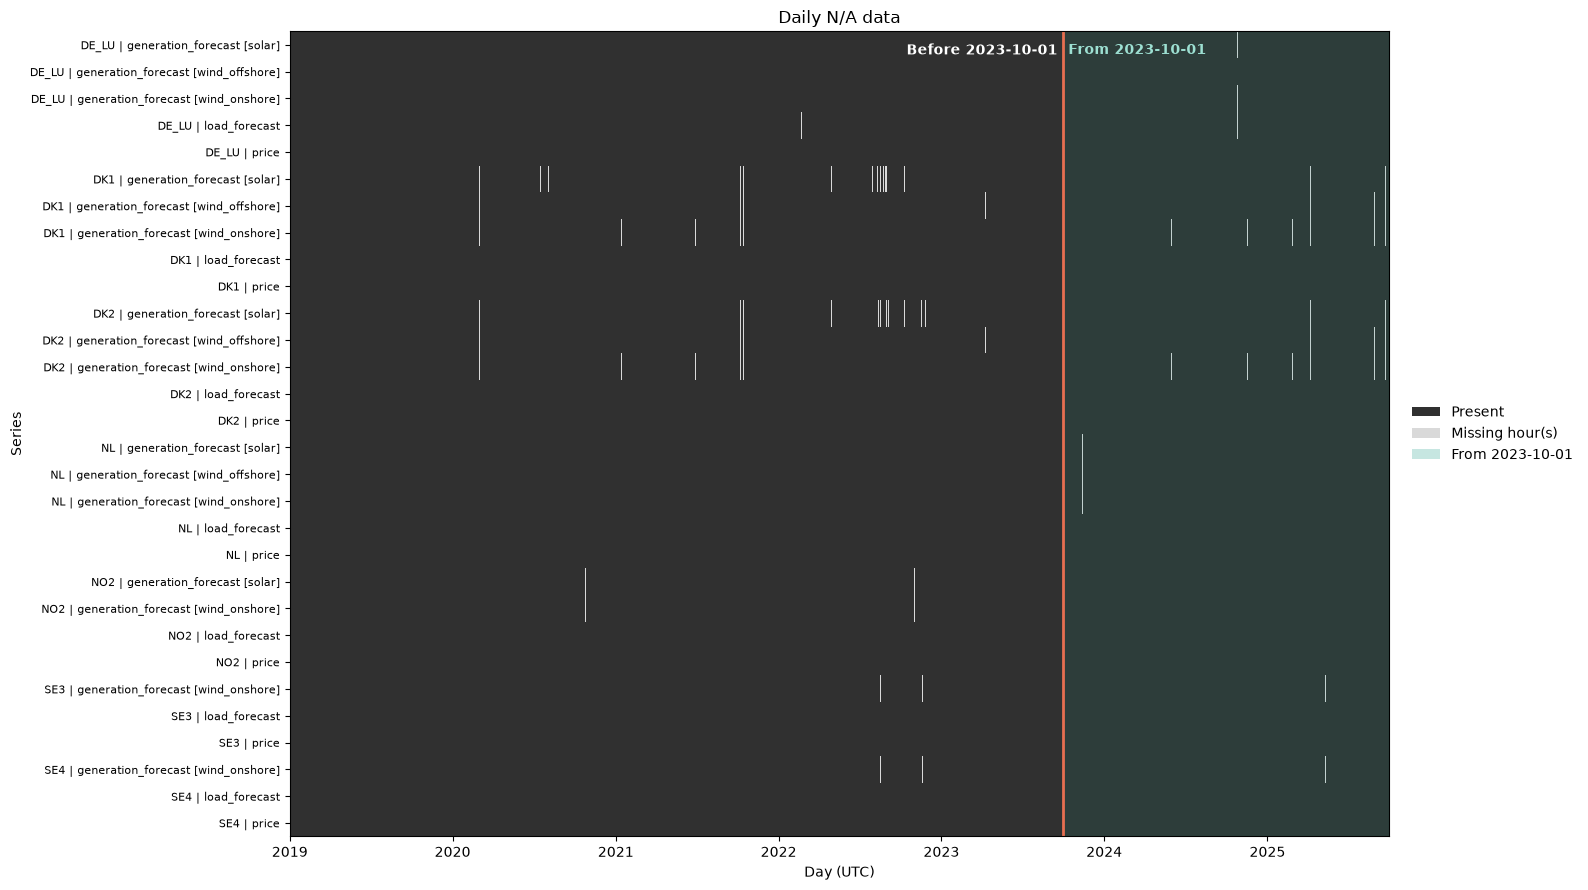

In [44]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch


def plot_missing_values(data, cutoff="2023-10-01"):
    """Plot whether each series contains every expected UTC hour per day."""
    series_order = sorted(data.series.unique())
    hour_grid = pd.date_range(
        data.timestamp_utc.min(), data.timestamp_utc.max(), freq="h"
    )
    day_grid = pd.date_range(
        hour_grid.min().floor("D"), hour_grid.max().floor("D"), freq="D"
    )
    expected = pd.Series(hour_grid.floor("D")).value_counts().reindex(day_grid)
    observed = (
        data.assign(day_utc=data.timestamp_utc.dt.floor("D"))
            .groupby(["series", "day_utc"], observed=True)
            .size()
            .unstack(fill_value=0)
            .reindex(index=series_order, columns=day_grid, fill_value=0)
    )
    daily_presence = observed.eq(expected, axis="columns")

    year_start = pd.Timestamp(year=day_grid.min().year, month=1, day=1, tz="UTC")
    year_starts = pd.date_range(year_start, day_grid.max(), freq="YS")
    year_starts = year_starts[year_starts >= day_grid.min()]
    year_positions = day_grid.searchsorted(year_starts)

    fig, ax = plt.subplots(figsize=(16, 9))
    ax.imshow(daily_presence.to_numpy(), aspect="auto", interpolation="nearest",
              cmap=ListedColormap(["#d9d9d9", "#303030"]), vmin=0, vmax=1)

    legend = [Patch(facecolor="#303030", label="Present"),
              Patch(facecolor="#d9d9d9", label="Missing hour(s)")]
    if cutoff is not None:
        cutoff = pd.Timestamp(cutoff, tz="UTC")
        cutoff_position = day_grid.searchsorted(cutoff) - 0.5
        if -0.5 < cutoff_position < len(day_grid) - 0.5:
            ax.axvspan(cutoff_position, len(day_grid) - 0.5,
                       color="#1f9e89", alpha=0.12)
            ax.axvline(cutoff_position, color="#e76f51", linewidth=2)
            ax.text(cutoff_position - 12, 0.985, f"Before {cutoff.date()}",
                    ha="right", va="top", transform=ax.get_xaxis_transform(),
                    color="white", fontweight="bold")
            ax.text(cutoff_position + 12, 0.985, f"From {cutoff.date()}",
                    ha="left", va="top", transform=ax.get_xaxis_transform(),
                    color="#9de0d2", fontweight="bold")
            legend.append(Patch(facecolor="#1f9e89", alpha=0.25,
                                label=f"From {cutoff.date()}"))

    ax.set_yticks(np.arange(len(series_order)), labels=series_order, fontsize=8)
    ax.set_xticks(year_positions, labels=year_starts.year)
    ax.set_xlabel("Day (UTC)")
    ax.set_ylabel("Series")
    ax.set_title("Daily N/A data")
    ax.legend(handles=legend, loc="center left", bbox_to_anchor=(1.01, 0.5),
              frameon=False)
    fig.tight_layout()
    plt.show()
    return fig, ax, daily_presence


fig, ax, daily_presence = plot_missing_values(panel)

Solar and load gaps are filled from the same hour one week earlier. Wind gaps are filled by cross-zonal OLS using available zones with the same wind type. Each wind model is fitted once at the start of a gap using only complete observations strictly before that gap; contemporaneous neighbour-zone forecasts supply the predictors for the missing hours. Predictions are clipped at zero.

In [48]:
WEEK = pd.Timedelta(days=7)
MIN_REGRESSION_HOURS = 24 * 28


def missing_hours(group):
    stamps = pd.DatetimeIndex(group.timestamp_utc.unique()).sort_values()
    return pd.date_range(stamps.min(), stamps.max(), freq="h").difference(stamps)


def gap_groups(stamps):
    values = pd.Series(stamps, index=stamps)
    breaks = (values.diff() != pd.Timedelta(hours=1)).cumsum()
    return [pd.DatetimeIndex(run.index) for _, run in values.groupby(breaks)]


def row_for_fill(group, timestamp):
    source = timestamp - WEEK
    prior_week = group[group.timestamp_utc == source]
    if len(prior_week):
        row = prior_week.iloc[0].copy()
    else:
        history = group[group.timestamp_utc < timestamp]
        if history.empty:
            raise KeyError(f"no earlier metadata row for {group.name!r} at {timestamp}")
        row = history.iloc[-1].copy()
    row["timestamp_utc"] = timestamp
    return row


def weekly_lag_fill(group, stamps):
    by_timestamp = group.set_index("timestamp_utc").to_dict("index")
    rows = []
    for timestamp in stamps:
        source = timestamp - WEEK
        if source not in by_timestamp:
            raise KeyError(
                f"{group.name!r} has no value at {source} to fill {timestamp} from"
            )
        row = dict(by_timestamp[source], timestamp_utc=timestamp,
                   imputation_method="same_hour_previous_week",
                   imputation_predictors="")
        rows.append(row)
        by_timestamp[timestamp] = row
    return rows


def wind_regression_fill(data, group, stamps):
    psr_type = group.psr_type.iloc[0]
    target_zone = str(group.zone.iloc[0])
    wind = data[
        (data.variable == "generation_forecast")
        & (data.psr_type == psr_type)
    ].pivot(index="timestamp_utc", columns="zone", values="value")
    wind.columns = wind.columns.astype(str)

    rows = []
    for run in gap_groups(stamps):
        predictors = [
            zone for zone in wind.columns
            if zone != target_zone
            and wind.loc[run, zone].notna().all()
        ]
        if not predictors:
            raise ValueError(f"no complete neighbour zone for {group.name!r} at {run[0]}")

        train = wind.loc[wind.index < run[0], [target_zone, *predictors]].dropna()
        if len(train) < MIN_REGRESSION_HOURS:
            raise ValueError(
                f"only {len(train)} past training hours for {group.name!r} at {run[0]}"
            )
        assert train.index.max() < run[0], "wind regression training leaked future data"

        x_train = train[predictors].to_numpy(dtype=float)
        y_train = train[target_zone].to_numpy(dtype=float)
        center = x_train.mean(axis=0)
        scale = x_train.std(axis=0)
        scale[scale == 0] = 1
        design = np.column_stack([np.ones(len(train)), (x_train - center) / scale])
        coefficients = np.linalg.lstsq(design, y_train, rcond=None)[0]

        x_gap = wind.loc[run, predictors].to_numpy(dtype=float)
        gap_design = np.column_stack([np.ones(len(run)), (x_gap - center) / scale])
        predictions = np.maximum(gap_design @ coefficients, 0)
        predictor_label = ",".join(predictors)

        for timestamp, prediction in zip(run, predictions):
            row = row_for_fill(group, timestamp)
            row["value"] = prediction
            row["imputation_method"] = "causal_cross_zone_ols"
            row["imputation_predictors"] = predictor_label
            rows.append(row.to_dict())
    return rows


def fill_exogenous_gaps(data):
    rows = []
    for series, group in data.groupby("series", observed=True):
        stamps = missing_hours(group)
        if not len(stamps):
            continue
        group = group.copy()
        group.name = series
        variable = group.variable.iloc[0]
        psr_type = group.psr_type.iloc[0]
        if variable == "load_forecast" or psr_type == "solar":
            rows.extend(weekly_lag_fill(group, stamps))
        elif psr_type in {"wind_onshore", "wind_offshore"}:
            rows.extend(wind_regression_fill(data, group, stamps))
        else:
            raise ValueError(f"no gap-filling rule for {series!r}")
    return pd.DataFrame(rows)


filled = fill_exogenous_gaps(panel)
filled["imputed"] = True

n = len(panel)
panel = pd.concat([
    panel.assign(imputed=False, imputation_method="observed",
                 imputation_predictors=""),
    filled,
], ignore_index=True).sort_values(["series", "timestamp_utc"], ignore_index=True)

assert not panel.duplicated(["series", "timestamp_utc"]).any(), \
    "filling created a duplicate series-hour"
assert gap_runs(panel).empty, "an hourly gap remains after filling"

print(f"fill exogenous gaps: {n:,} -> {len(panel):,}  (+{len(filled):,})")
display(filled.groupby(["imputation_method", "series"], observed=True)
              .size().rename("hours_filled").to_frame())

fill exogenous gaps: 1,772,550 -> 1,774,740  (+2,190)


hours_filled
imputation_method       series                                                  
causal_cross_zone_ols   DE_LU | generation_forecast [wind_onshore]             2
                        DK1 | generation_forecast [wind_offshore]            216
                        DK1 | generation_forecast [wind_onshore]             306
                        DK2 | generation_forecast [wind_offshore]            216
                        DK2 | generation_forecast [wind_onshore]             312
                        NL | generation_forecast [wind_offshore]              24
                        NL | generation_forecast [wind_onshore]               24
                        NO2 | generation_forecast [wind_onshore]              50
                        SE3 | generation_forecast [wind_onshore]              96
                        SE4 | generation_forecast [wind_onshore]              96
same_hour_previous_week DE_LU | generation_forecast [solar]                    2
                        DE_LU | load_forecast                                 50
                        DK1 | generation_forecast [solar]                    384
                        DK2 | generation_forecast [solar]                    338
                        NL | generation_forecast [solar]                      24
                        NO2 | generation_forecast [solar]                     50

In [52]:
variance_summary = (
    panel.groupby("series", observed=True)["value"]
         .agg(observations="size", mean="mean", mean_abs=lambda s: s.abs().mean(),
              variance="var", std_dev="std", minimum="min", maximum="max",
              unique_values="nunique")
)
variance_summary["range"] = variance_summary.maximum - variance_summary.minimum
variance_summary["relative_std_pct"] = (
    100 * variance_summary.std_dev
    / variance_summary.mean_abs.replace(0, np.nan)
)
variance_summary["exactly_constant"] = variance_summary.unique_values <= 1
variance_summary["practically_zero_variance"] = (
    variance_summary.exactly_constant
    | (variance_summary.std_dev <= 0.001 * variance_summary.mean_abs)
)
variance_summary = variance_summary.sort_values(
    ["practically_zero_variance", "relative_std_pct"],
    ascending=[False, True],
)

print(f"{int(variance_summary.exactly_constant.sum())} exactly constant series")
print(f"{int(variance_summary.practically_zero_variance.sum())} series with "
      f"std. dev. <= 0.1% of their mean absolute level")
display(variance_summary.round({
    "mean": 4, "mean_abs": 4, "variance": 4, "std_dev": 4,
    "minimum": 4, "maximum": 4, "range": 4, "relative_std_pct": 6,
}))

0 exactly constant series
0 series with std. dev. <= 0.1% of their mean absolute level


,observations,mean,mean_abs,variance,std_dev,minimum,maximum,unique_values,range,relative_std_pct,exactly_constant,practically_zero_variance
series,,,,,,,,,,,,
DE_LU | load_forecast,59158,54612.8107,54612.8107,8.544941e+07,9243.8852,30893.0550,78154.3700,58998,47261.3150,16.926221,False,False
DK1 | load_forecast,59158,2475.6264,2475.6264,2.007155e+05,448.0129,1171.0000,3943.0000,7737,2772.0000,18.096950,False,False
DK2 | load_forecast,59158,1540.9408,1540.9408,8.798490e+04,296.6225,819.0000,2559.0000,6493,1740.0000,19.249441,False,False
NL | load_forecast,59158,11398.5767,11398.5767,5.051399e+06,2247.5317,478.7700,21256.9225,58605,20778.1525,19.717652,False,False
NO2 | load_forecast,59158,3936.0261,3936.0261,6.799693e+05,824.6025,1951.9700,6759.7400,54322,4807.7700,20.950129,False,False
SE3 | load_forecast,59158,9645.7931,9645.7931,4.482669e+06,2117.2315,5130.0000,16856.0000,9210,11726.0000,21.949792,False,False
SE4 | load_forecast,59158,2600.2161,2600.2161,3.798504e+05,616.3200,1301.0000,4921.0000,2997,3620.0000,23.702646,False,False
DK1 | generation_forecast [wind_offshore],59158,543.3390,543.3390,1.052209e+05,324.3777,0.0000,1157.9200,29071,1157.9200,59.700801,False,False
DE_LU | generation_forecast [wind_offshore],59158,2818.3840,2818.3840,3.420411e+06,1849.4354,12.9050,6834.5025,58526,6821.5975,65.620418,False,False


In [53]:
NO2_SOLAR = "NO2 | generation_forecast [solar]"

n_rows = len(panel)
n_series = panel.series.nunique()
panel = panel[panel.series != NO2_SOLAR].copy()

assert NO2_SOLAR not in set(panel.series), "NO2 solar forecast survived"
print(f"drop series {NO2_SOLAR!r}: "
      f"{n_series} -> {panel.series.nunique()} series, "
      f"{n_rows:,} -> {len(panel):,} rows  (-{n_rows - len(panel):,})")

drop series 'NO2 | generation_forecast [solar]': 29 -> 29 series, 1,715,582 -> 1,715,582 rows  (-0)


In [54]:
OUT = RAW.parent / "nordic_baltic_clean_hourly_utc.parquet"

assert not panel.duplicated(["series", "timestamp_utc"]).any(), \
    "duplicate series-hour before export"
assert not panel.value.isna().any(), "missing values before export"
assert gap_runs(panel).empty, "an hourly gap remains before export"

panel.to_parquet(OUT, index=False)

print(f"written: {OUT.resolve()}")
print(f"{len(panel):,} rows x {panel.shape[1]} columns | "
      f"{panel.series.nunique()} series | {OUT.stat().st_size / 1e6:.1f} MB")

written: C:\Users\Frede\OneDrive\Skrivebord\Masters Thesis v2\Code\EPF_Masters\datasets\nordic_baltic_clean_hourly_utc.parquet
1,715,582 rows x 20 columns | 29 series | 12.0 MB
